In [1]:
!apt-get -y install fonts-ipafont-gothic
!pip install japanize-matplotlib

'apt-get' �́A�����R�}���h�܂��͊O���R�}���h�A
����\�ȃv���O�����܂��̓o�b�` �t�@�C���Ƃ��ĔF������Ă��܂���B


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\kyohe\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


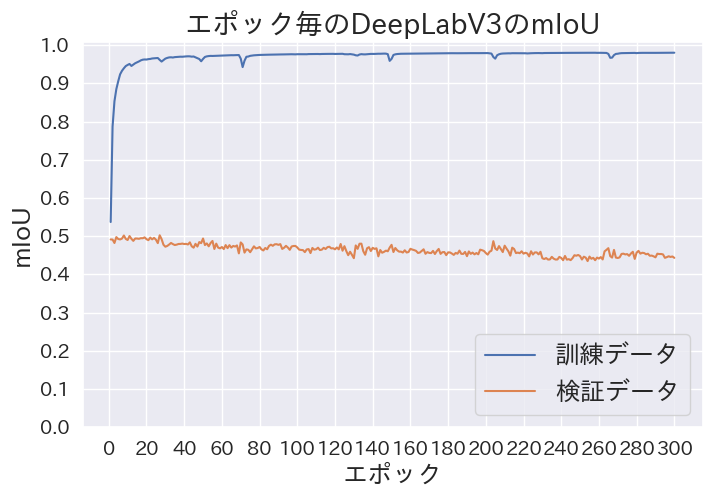

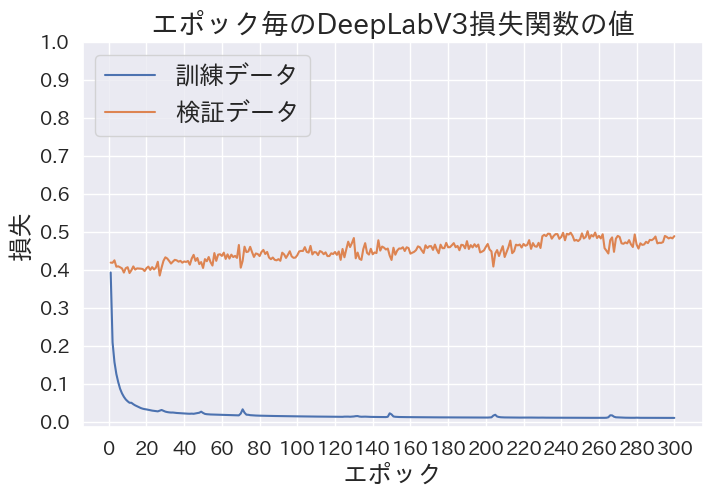

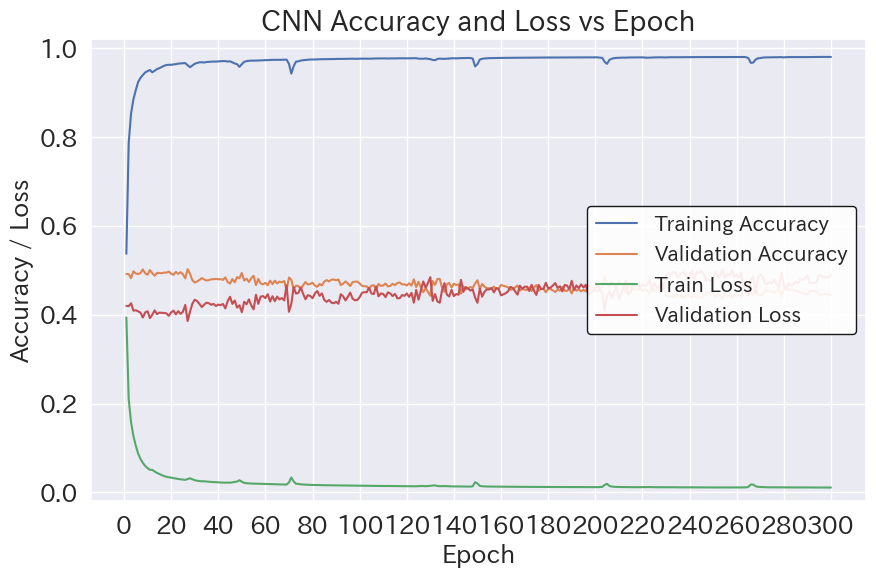

In [5]:
#2回目グラフ
import pandas as pd
import numpy as np
# グラフを描画するライブラリ
from matplotlib import pyplot as plt
import seaborn as sns
sns.set() # seabornの設定を無効化
sns.reset_orig() # seabornの設定をリセットしてmatplotlibのデフォルトに戻す
import matplotlib.pyplot as plt
import japanize_matplotlib
import datetime as dt
from pathlib import Path
%matplotlib inline

# matplotlibのスタイルを明示的に設定（seabornの影響を排除）
plt.style.use('default')  # matplotlibのデフォルトスタイルを使用
#seabornのフォントは必ずjapanize_matplotlibのデフォルトのやつに合わせること　でないと文字化け
sns.set(font='IPAexGothic')

csv_path=r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\History\\"
filedate="20260107_1428"

df=pd.read_csv(Path(csv_path + filedate + f"/history_{filedate}.csv"))

ep=np.arange(1, len(df)+1)
epochs=len(df)

def plot_acc(train_accuracies, val_accuracies):
    plt.figure(figsize=(8, 5))
    plt.plot(ep, train_accuracies)
    plt.plot(ep, val_accuracies)
    plt.title("エポック毎のDeepLabV3のmIoU", fontsize=20)
    plt.ylabel("mIoU", fontsize=18)
    plt.xlabel("エポック", fontsize=18)
    plt.xticks(np.arange(0, epochs+1, 20), fontsize=14)
    plt.yticks(np.arange(0.0, 1.05, 0.1), fontsize=14)
    plt.legend(["訓練データ", "検証データ"], loc="lower right", fontsize=18)
    plt.show()

def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(ep, train_losses)
    plt.plot(ep, val_losses)
    plt.title("エポック毎のDeepLabV3損失関数の値", fontsize=20)
    plt.ylabel("損失", fontsize=18)
    plt.xlabel("エポック", fontsize=18)
    plt.xticks(np.arange(0, epochs+1, 20), fontsize=14)
    plt.yticks(np.arange(0.0, 1.05, 0.1), fontsize=14)
    plt.legend(["訓練データ", "検証データ"], loc="upper left", fontsize=18)
    plt.show()

def plot_accuracy_and_loss(train_accuracies, val_accuracies, train_losses, val_losses):
    # figure()でグラフを描画する領域を確保，figというオブジェクトにする．
    fig = plt.figure(figsize=(10, 6))

    # add_subplot()でグラフを描画する領域を追加する．引数は行，列，場所
    ax1 = fig.add_subplot(1, 1, 1)
    # ax2 = ax1.twinx()   # x軸を共有
    ax1.set_axisbelow(True)
    # ax2.set_axisbelow(True)
    plt.rcParams['axes.axisbelow'] = True
    # グリッドのzorderを設定（凡例より奥に）
    ax1.grid(True, zorder=1)
    # ax2.grid(True, zorder=1)

    c1, c2, c3, c4 = "blue", "red", "green", "yellow"  # 各プロットの色
    l1, l2, l3, l4 = "Training Accuracy", "Validation Accuracy", "Train Loss", "Validation Loss" # 各ラベル

    # 1つ目のグラフを描画
    ax1.plot(ep, train_accuracies, label=l1)
    ax1.plot(ep, val_accuracies, label=l2)
    ax1.plot(ep, train_losses, label=l3)
    ax1.plot(ep, val_losses, label=l4)




    # 凡例を統合
    h1, l1 = ax1.get_legend_handles_labels()
    # h2, l2 = ax2.get_legend_handles_labels()

    legend = ax1.legend(h1, l1, loc='right', frameon=True, fontsize=15) # ax1とax2の凡例のhandlerとlabelのリストを結合
    legend.set_zorder(1000)  # 凡例を前面に表示
    legend.get_frame().set_facecolor('white')  # 凡例の背景を白に設定
    legend.get_frame().set_alpha(0.9)  # 凡例の背景の透明度を設定
    legend.get_frame().set_edgecolor('black')  # 凡例の枠線を黒に設定



    ax1.set_xlabel('Epoch', fontsize=18) #x軸ラベル
    ax1.set_ylabel('Accuracy / Loss', fontsize=18) #y軸ラベル
    ax1.set_xticks(np.arange(0, epochs+1, 20))
    ax1.set_yticks(np.arange(0.0, 1.05, 0.2))
    ax1.set_ylim(-0.02, 1.02)
    ax1.set_title("CNN Accuracy and Loss vs Epoch", fontsize=20) #グラフタイトル

    # 目盛りのフォントサイズを18に設定
    ax1.tick_params(axis='x', labelsize=18)
    ax1.tick_params(axis='y', labelsize=18)

    # 2つ目のグラフを描画
    # ax2.set_ylabel('Loss', fontsize=18) #y軸ラベル
    # ax2.set_yticks(np.arange(0.0, 1.05, 0.2))
    # ax2.set_ylim(-0.02, 1.02)

    plt.show()




plot_acc(df["train_mIoU"], df["val_mIoU"])
plot_loss(df["train_loss"], df["val_loss"])
plot_accuracy_and_loss(df["train_mIoU"], df["val_mIoU"], df["train_loss"], df["val_loss"])

In [ ]:
import torch
    plt.plot(ep, train_accuracies)
    plt.plot(ep, val_accuracies)
    plt.plot(ep, train_losses)
    plt.plot(ep, val_losses)
    plt.title("CNN Accuracy and Loss vs Epoch", fontsize=20)
    plt.ylabel("Accuracy", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.xlabel("Epoch", fontsize=18)
    plt.xticks(np.arange(0, epochs+1, 10), fontsize=18)
    plt.yticks(np.arange(0.0, 1.05, 0.1), fontsize=18)
    plt.legend(["Training Accuracy", "Validation Accuracy", "Train Loss", "Validation Loss"], loc="upper left", fontsize=18)
    plt.show()